## Subject Visualizations

Plots key variables for 10 selected subjects in subplots.

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import random

from src.config import PROCESSED_DATA_DIR

In [ ]:
interday = pd.read_csv(PROCESSED_DATA_DIR / "features_interday.csv")
intraday = pd.read_csv(PROCESSED_DATA_DIR / "features_intraday.csv", parse_dates=["datetime"])

Selected subjects: [np.int64(2), np.int64(20), np.int64(22), np.int64(23), np.int64(33), np.int64(34)]


In [ ]:
print(f"All cycles: {interday.groupby(['id','cycle_id']).ngroups}  |  subjects: {interday['id'].nunique()}")
interday = interday[interday["is_complete_cycle"]].copy()
complete_pairs = interday[["id", "cycle_id"]].drop_duplicates()
intraday = intraday.merge(complete_pairs, on=["id", "cycle_id"])
print(f"Complete cycles: {interday.groupby(['id','cycle_id']).ngroups}  |  subjects: {interday['id'].nunique()}")

subject_ids = sorted(random.sample(list(interday["id"].unique()), 30))

All cycles: 126  |  subjects: 38
Complete cycles: 88  |  subjects: 37


In [14]:
PHASE_ORDER = ["Menstrual", "Follicular", "Fertility", "Luteal"]
PHASE_COLORS = {
    "Menstrual": "#ca0020",
    "Follicular": "#ef8a62",
    "Fertility": "#67a9cf",
    "Luteal": "#0571b0",
}
REPORT_COLS = [
    "appetite", "exerciselevel", "headaches", "cramps", "sorebreasts",
    "fatigue", "sleepissue", "moodswing", "stress", "foodcravings",
    "indigestion", "bloating",
]

### Hormone trajectories

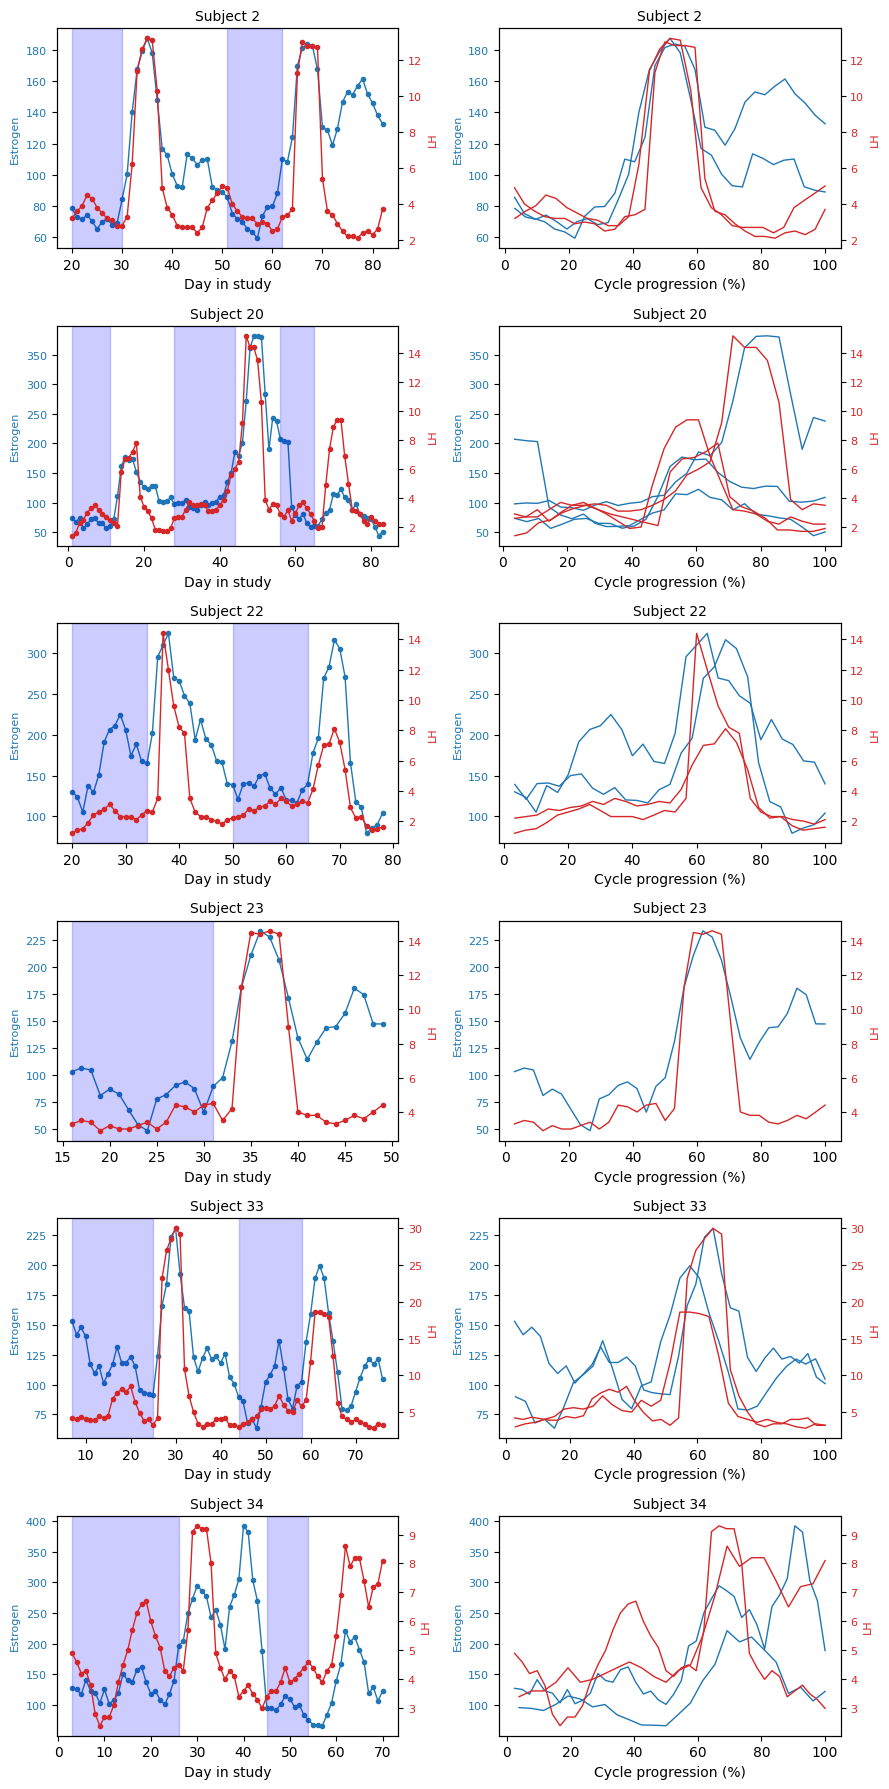

In [58]:
fig, axes = plt.subplots(len(subject_ids), 2, figsize=(9, 3 * len(subject_ids)))

for row, sid in enumerate(subject_ids):
    grp = interday[interday["id"] == sid].sort_values("day_in_study")
    for col, xcol, xlabel in [
        (0, "day_in_study", "Day in study"),
        (1, "cycle_pct", "Cycle progression (%)"),
    ]:
        ax = axes[row, col]
        ax2 = ax.twinx()
        if xcol == "cycle_pct":
            for _, cyc in grp.groupby("cycle_id"):
                ax.plot(cyc[xcol], cyc["estrogen_smooth"], color="tab:blue", linewidth=1)
                ax2.plot(cyc[xcol], cyc["lh_smooth"], color="tab:red", linewidth=1)
        else:
            ax.plot(grp[xcol], grp["estrogen_smooth"], marker="o", markersize=3, color="tab:blue", linewidth=1)
            ax2.plot(grp[xcol], grp["lh_smooth"], marker="o", markersize=3, color="tab:red", linewidth=1)
        ax.set_ylabel("Estrogen", color="tab:blue", fontsize=8)
        ax2.set_ylabel("LH", color="tab:red", fontsize=8)
        ax.tick_params(axis="y", labelcolor="tab:blue", labelsize=8)
        ax2.tick_params(axis="y", labelcolor="tab:red", labelsize=8)
        ax.set_title(f"Subject {sid}", fontsize=10)
        ax.set_xlabel(xlabel, fontsize=10)
        if col == 0:
            mask = grp["phase_dual"] == "Follicular"
            changes = mask.ne(mask.shift()).cumsum()
            for i, (_, segment) in enumerate(grp[mask].groupby(changes[mask])):
                plt.axvspan(segment["day_in_study"].min(), segment["day_in_study"].max(), alpha=0.2, color="blue",
                            label="Follicular" if i == 0 else "_nolegend_")

fig.tight_layout()
plt.show()

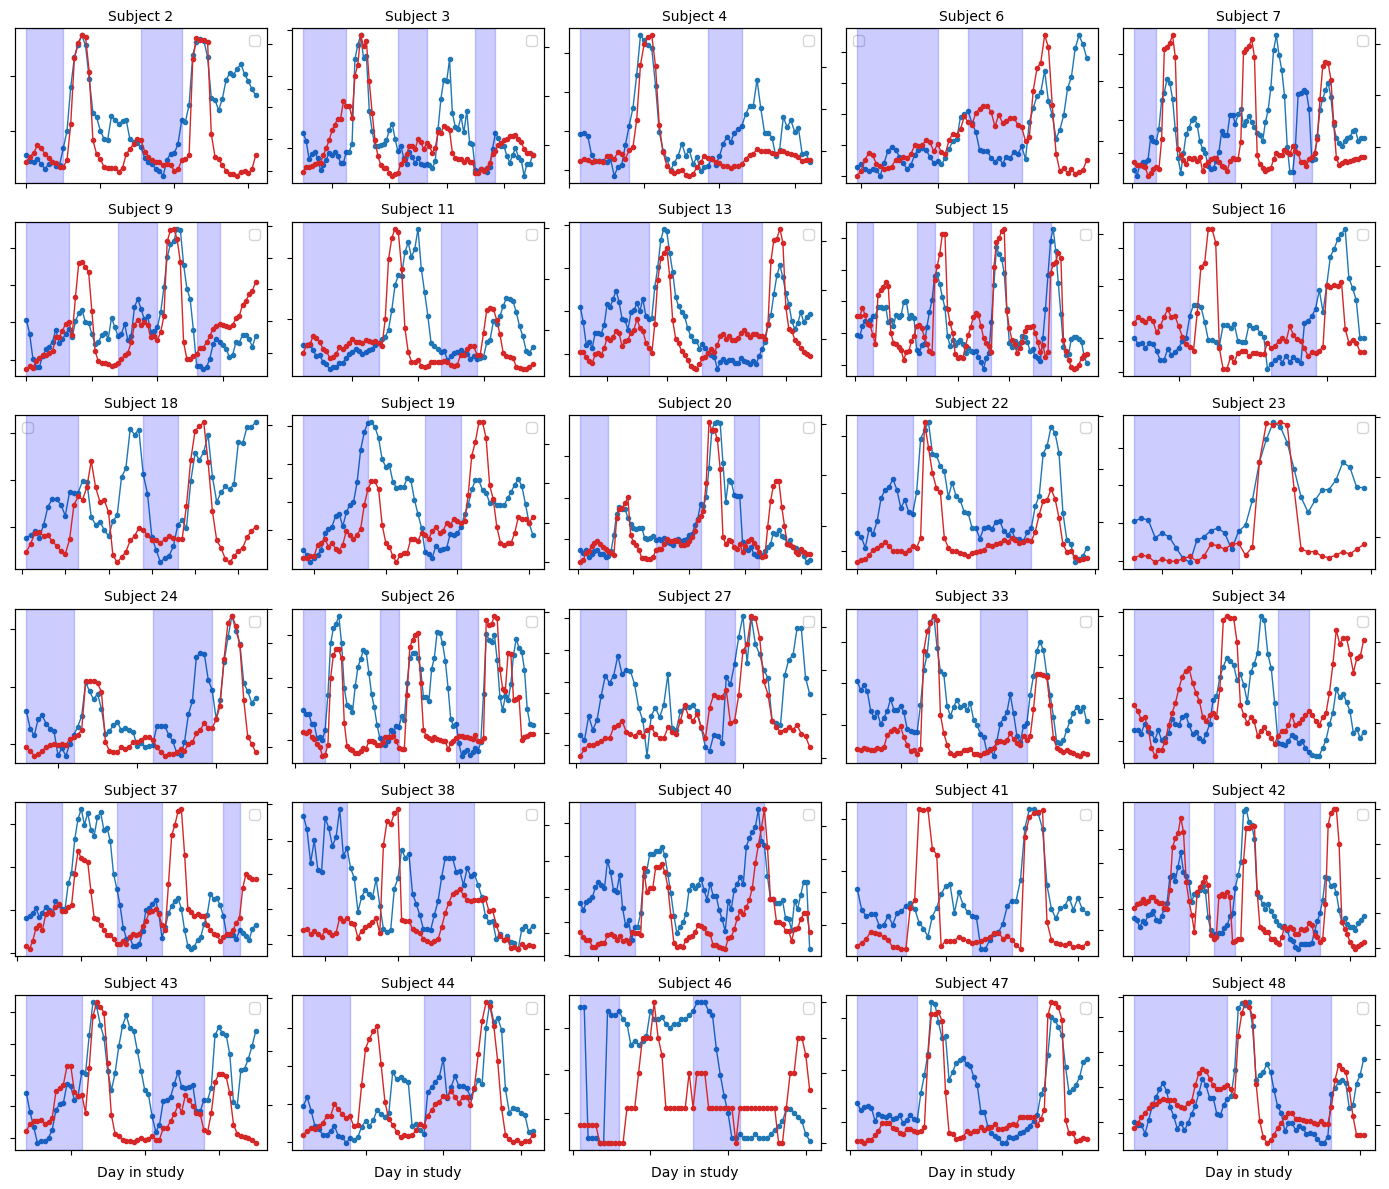

In [ ]:
fig, axes = plt.subplots(6, 5, figsize=(14, 12))
axes = axes.flatten()

for i, sid in enumerate(subject_ids):
    grp = interday[interday["id"] == sid].sort_values("day_in_study")
    ax = axes[i]
    ax2 = ax.twinx()
    row, col = divmod(i, 5)
    ax.plot(grp["day_in_study"], grp["estrogen_smooth"], marker="o", markersize=3, color="tab:blue", linewidth=1)
    ax2.plot(grp["day_in_study"], grp["lh_smooth"], marker="o", markersize=3, color="tab:red", linewidth=1)
    ax.set_xticklabels([])
    ax2.set_yticklabels([])
    ax2.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(f"Subject {sid}", fontsize=9)
    if row == 5:
        ax.set_xlabel("Day in study", fontsize=9)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    if row == 0 and col == 4:
        ax.legend(lines1 + lines2, labels1 + labels2)

    mask = grp["phase_dual"] == "Follicular"
    changes = mask.ne(mask.shift()).cumsum()
    for i, (_, segment) in enumerate(grp[mask].groupby(changes[mask])):
        plt.axvspan(segment["day_in_study"].min(), segment["day_in_study"].max(), alpha=0.2, color="blue",
                    label="Follicular" if i == 0 else "_nolegend_")

fig.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(6, 5, figsize=(14, 12))
axes = axes.flatten()

for i, sid in enumerate(subject_ids):
    grp = interday[interday["id"] == sid].sort_values("day_in_study")
    grp["temperature_smooth"] = grp["temperature"].transform(lambda x: x.rolling(window=5, center=True, min_periods=1).mean()).round(1)
    ax = axes[i]
    row, col = divmod(i, 5)
    ax.plot(grp["day_in_study"], grp["temperature_smooth"], marker="o", markersize=3, color="tab:blue", linewidth=1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(f"Subject {sid}", fontsize=9)
    if row == 5:
        ax.set_xlabel("Day in study", fontsize=9)
    lines1, labels1 = ax.get_legend_handles_labels()
    if row == 0 and col == 4:
        ax.legend(lines1, labels1)

    mask = grp["phase_dual"] == "Follicular"
    changes = mask.ne(mask.shift()).cumsum()
    for i, (_, segment) in enumerate(grp[mask].groupby(changes[mask])):
        plt.axvspan(segment["day_in_study"].min(), segment["day_in_study"].max(), alpha=0.2, color="blue",
                    label="Follicular" if i == 0 else "_nolegend_")

fig.tight_layout()
plt.show()

In [ ]:

for row, sid in enumerate(subject_ids):
    grp = interday[interday["id"] == sid].sort_values("day_in_study")
    for col, xcol, xlabel in [
        (0, "day_in_study", "Day in study"),
        (1, "cycle_pct", "Cycle progression (%)"),
    ]:
        ax = axes[row, col]
        ax2 = ax.twinx()
        if xcol == "cycle_pct":
            for _, cyc in grp.groupby("cycle_id"):
                ax.plot(cyc[xcol], cyc["estrogen_smooth"], color="tab:blue", linewidth=1)
                ax2.plot(cyc[xcol], cyc["lh_smooth"], color="tab:red", linewidth=1)
        else:
            ax.plot(grp[xcol], grp["estrogen_smooth"], marker="o", markersize=3, color="tab:blue", linewidth=1)
            ax2.plot(grp[xcol], grp["lh_smooth"], marker="o", markersize=3, color="tab:red", linewidth=1)
        ax.set_ylabel("Estrogen", color="tab:blue", fontsize=8)
        ax2.set_ylabel("LH", color="tab:red", fontsize=8)
        ax.tick_params(axis="y", labelcolor="tab:blue", labelsize=8)
        ax2.tick_params(axis="y", labelcolor="tab:red", labelsize=8)
        ax.set_title(f"Subject {sid}", fontsize=10)
        ax.set_xlabel(xlabel, fontsize=10)
        if col == 0:
            mask = grp["phase_dual"] == "Follicular"
            changes = mask.ne(mask.shift()).cumsum()
            for i, (_, segment) in enumerate(grp[mask].groupby(changes[mask])):
                plt.axvspan(segment["day_in_study"].min(), segment["day_in_study"].max(), alpha=0.2, color="blue",
                            label="Follicular" if i == 0 else "_nolegend_")

fig.tight_layout()
plt.show()

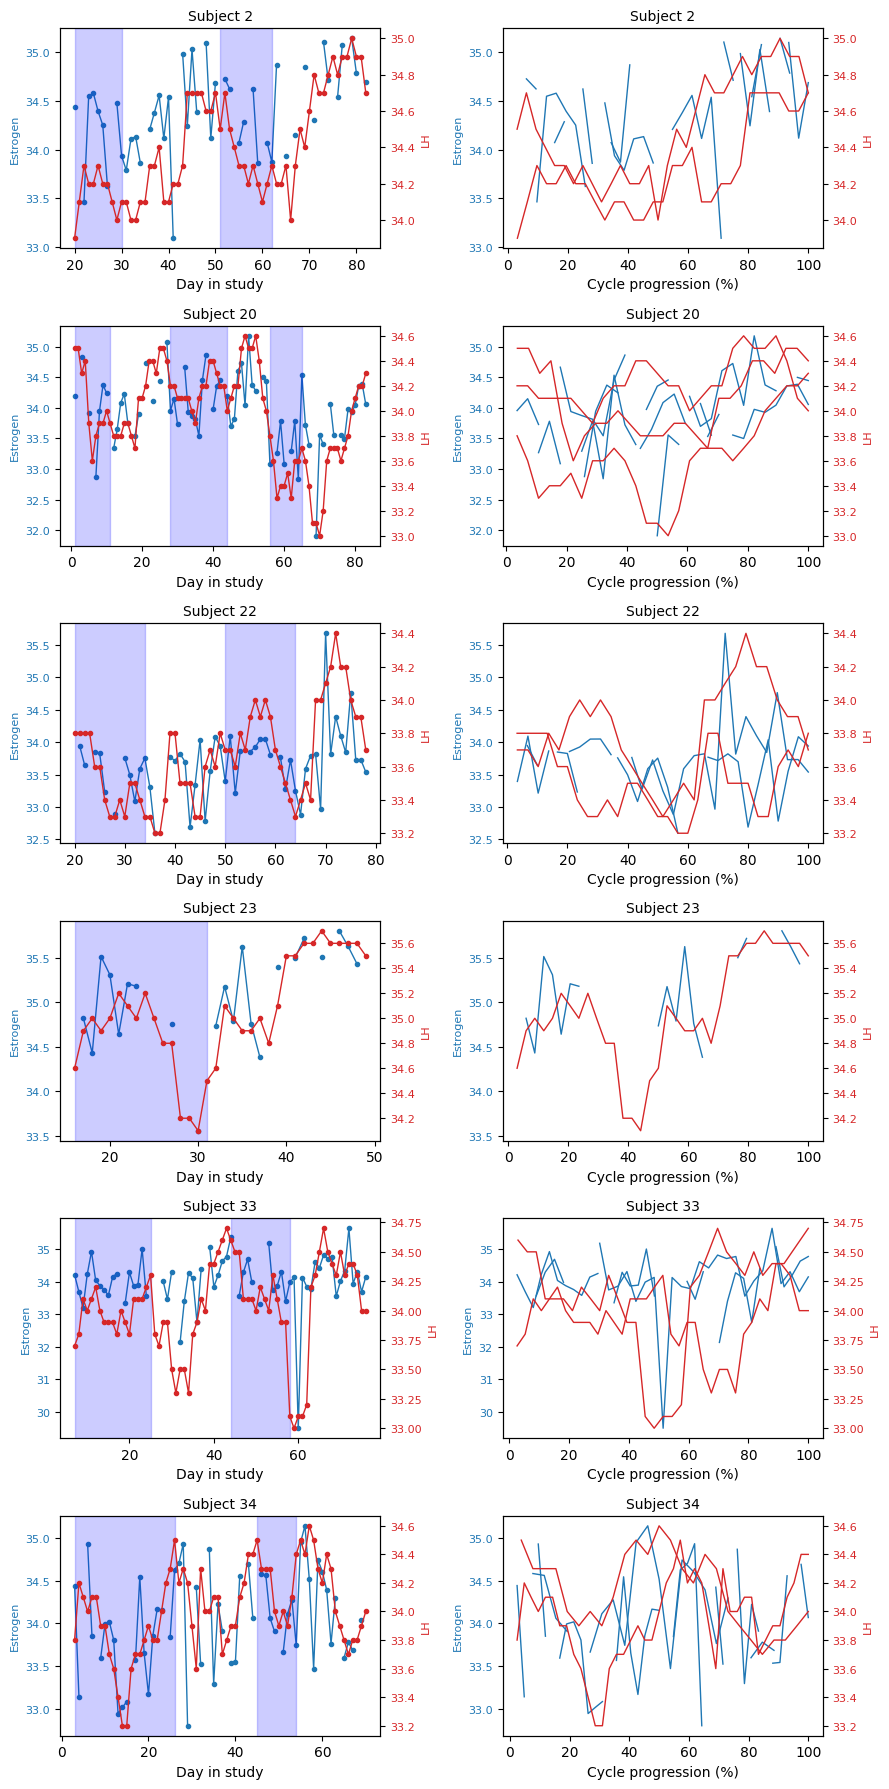

In [59]:
fig, axes = plt.subplots(len(subject_ids), 2, figsize=(9, 3 * len(subject_ids)))

for row, sid in enumerate(subject_ids):
    grp = interday[interday["id"] == sid].sort_values("day_in_study")
    grp["temperature_smooth"] = grp["temperature"].transform(lambda x: x.rolling(window=5, center=True, min_periods=1).mean()).round(1)
    grp["hrv_smooth"] = grp["heart_rate_var_mean"].transform(lambda x: x.rolling(window=5, center=True, min_periods=1).mean()).round(1)
    for col, xcol, xlabel in [
        (0, "day_in_study", "Day in study"),
        (1, "cycle_pct", "Cycle progression (%)"),
    ]:
        ax = axes[row, col]
        ax2 = ax.twinx()
        if xcol == "cycle_pct":
            for _, cyc in grp.groupby("cycle_id"):
                ax.plot(cyc[xcol], cyc["temperature"], color="tab:blue", linewidth=1)
                ax2.plot(cyc[xcol], cyc["temperature_smooth"], color="tab:red", linewidth=1)
        else:
            ax.plot(grp[xcol], grp["temperature"], marker="o", markersize=3, color="tab:blue", linewidth=1)
            ax2.plot(grp[xcol], grp["temperature_smooth"], marker="o", markersize=3, color="tab:red", linewidth=1)
        ax.set_ylabel("Estrogen", color="tab:blue", fontsize=8)
        ax2.set_ylabel("LH", color="tab:red", fontsize=8)
        ax.tick_params(axis="y", labelcolor="tab:blue", labelsize=8)
        ax2.tick_params(axis="y", labelcolor="tab:red", labelsize=8)
        ax.set_title(f"Subject {sid}", fontsize=10)
        ax.set_xlabel(xlabel, fontsize=10)
        if col == 0:
            mask = grp["phase_dual"] == "Follicular"
            changes = mask.ne(mask.shift()).cumsum()
            for i, (_, segment) in enumerate(grp[mask].groupby(changes[mask])):
                plt.axvspan(segment["day_in_study"].min(), segment["day_in_study"].max(), alpha=0.2, color="blue",
                            label="Follicular" if i == 0 else "_nolegend_")

fig.tight_layout()
plt.show()